# Predicting California Housing Prices Using Classical and Deep Machine Learning Methods

In [40]:
# All libraries needed for the analysis, 

import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("housing.csv")


df.head()
df.info()
df.isnull().sum()
df.describe()
# To first explore the nature of the data. 

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [14]:
print("Before removing rows with missing values:")
print("Total Missing Counts", df.isnull().sum())
display(df)

df_cleaned = df.dropna()
print("--" * 70)

print("After removing rows with missing values:")
print("Total Missing Counts", df_cleaned.isnull().sum())
display(df_cleaned)

Before removing rows with missing values:
Total Missing Counts longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND


--------------------------------------------------------------------------------------------------------------------------------------------
After removing rows with missing values:
Total Missing Counts longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND


In [ ]:
# Since Ocean Proximity is non-numerical, I will convert it to indicator varibles using one-hot encoding.

df_cleaned = pd.get_dummies(df_cleaned, columns=["ocean_proximity"], drop_first=True, dtype = int)
# Dropping the first column to remove redundancy and prevents a unique solution that could confuse a model. 
print('After performing One-hot Encoding')
display(df_cleaned)

After performing One-hot Encoding


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,0,0,1,0
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,0,0,1,0
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,0,0,1,0
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,0,0,1,0
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,1,0,0,0
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,1,0,0,0
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,1,0,0,0
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,1,0,0,0


In [17]:
# Separating features from targets. 

X = df_cleaned.drop("median_house_value", axis=1)

y = df_cleaned["median_house_value"]

display(X)
print("--" * 70)
display(y)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,0,0,1,0
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,0,0,1,0
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,0,0,1,0
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,0,0,1,0
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,1,0,0,0
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,1,0,0,0
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,1,0,0,0
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,1,0,0,0


--------------------------------------------------------------------------------------------------------------------------------------------


0        452600
1        358500
2        352100
3        341300
4        342200
          ...  
20635     78100
20636     77100
20637     92300
20638     84700
20639     89400
Name: median_house_value, Length: 20433, dtype: int64

In [21]:
# Splitting the data for training and testing. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [22]:
# The data has both large and small values, which can be misleading for a model.
# Therefore, I used standardization to transform the data so that the mean becomes 0 and the standard deviation becomes 1. 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

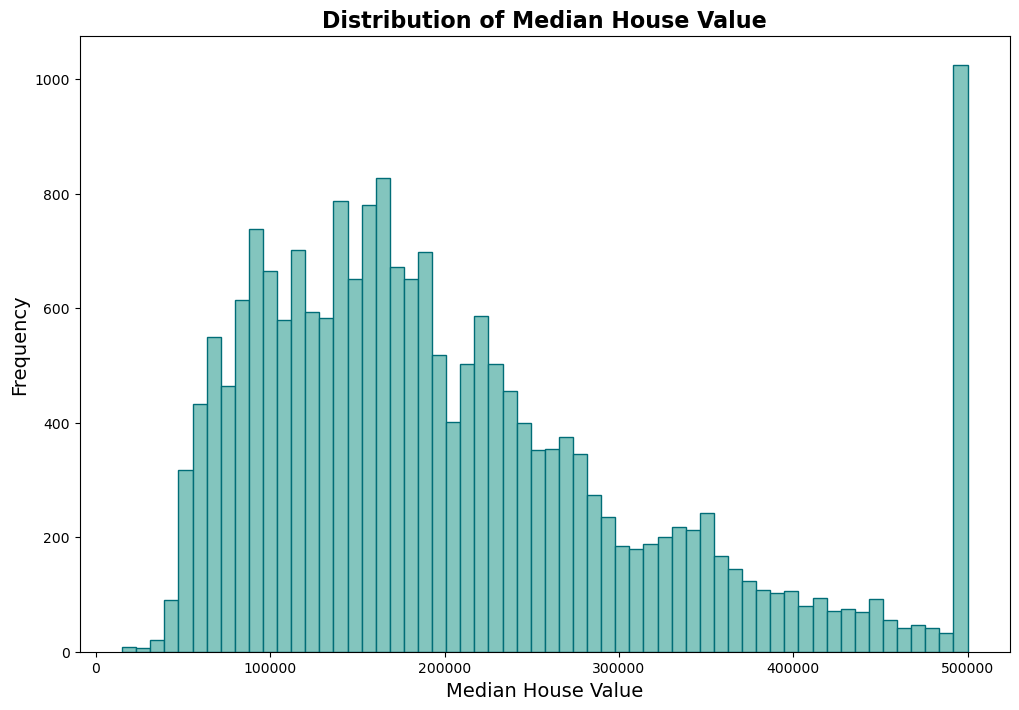

In [38]:
plt.figure(figsize=(12,8))

plt.hist(df["median_house_value"], bins=60, color="#83c5be", edgecolor="#006d77")
plt.xlabel("Median House Value", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Distribution of Median House Value", fontsize=16,fontweight="bold")
plt.show()

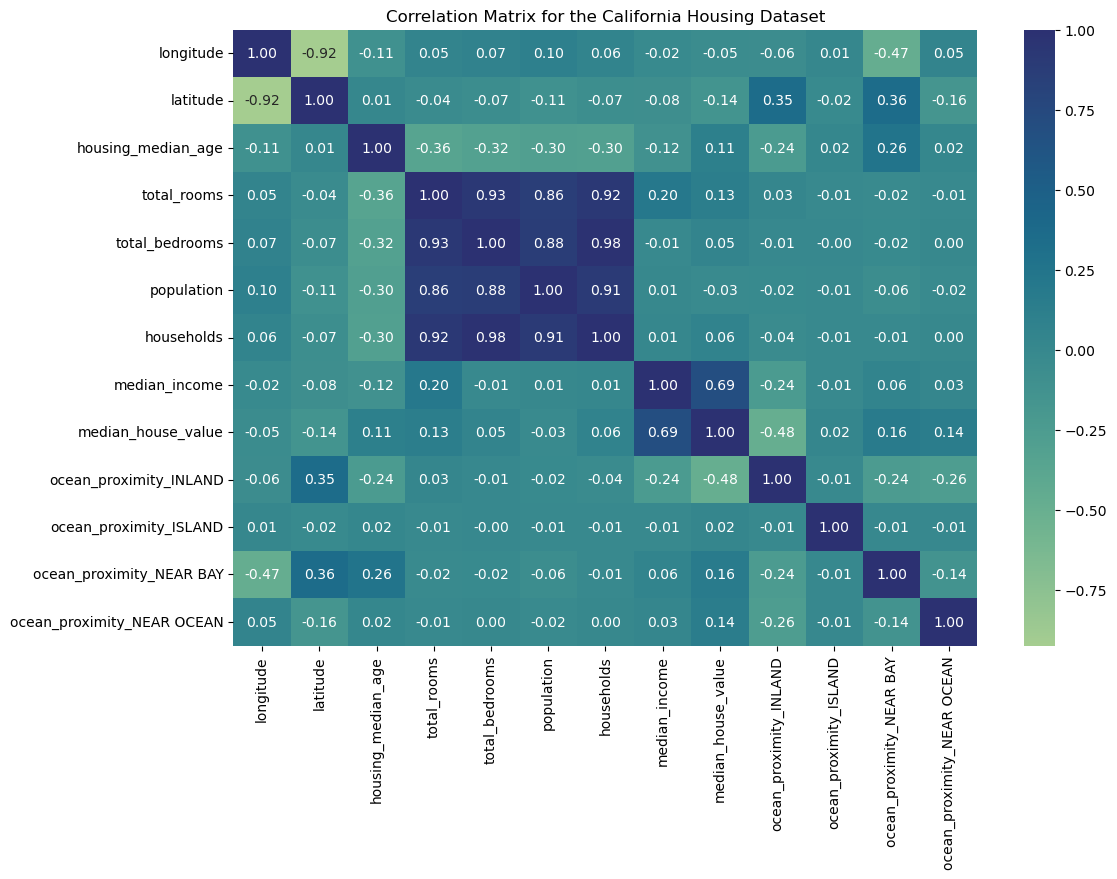

In [45]:
plt.figure(figsize=(12,8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap="crest", fmt=".2f")

plt.title("Correlation Matrix for the California Housing Dataset")
plt.show()

#### The correlation matrix shows that total_rooms, total_bedrooms, population, and households are strongly associated, which indicates multicollinearity. However, median_income is positively associated with median_house_value (r = 0.69). Also, INLAND houses are negatively correlated with with median_house_value (r = -0.48).

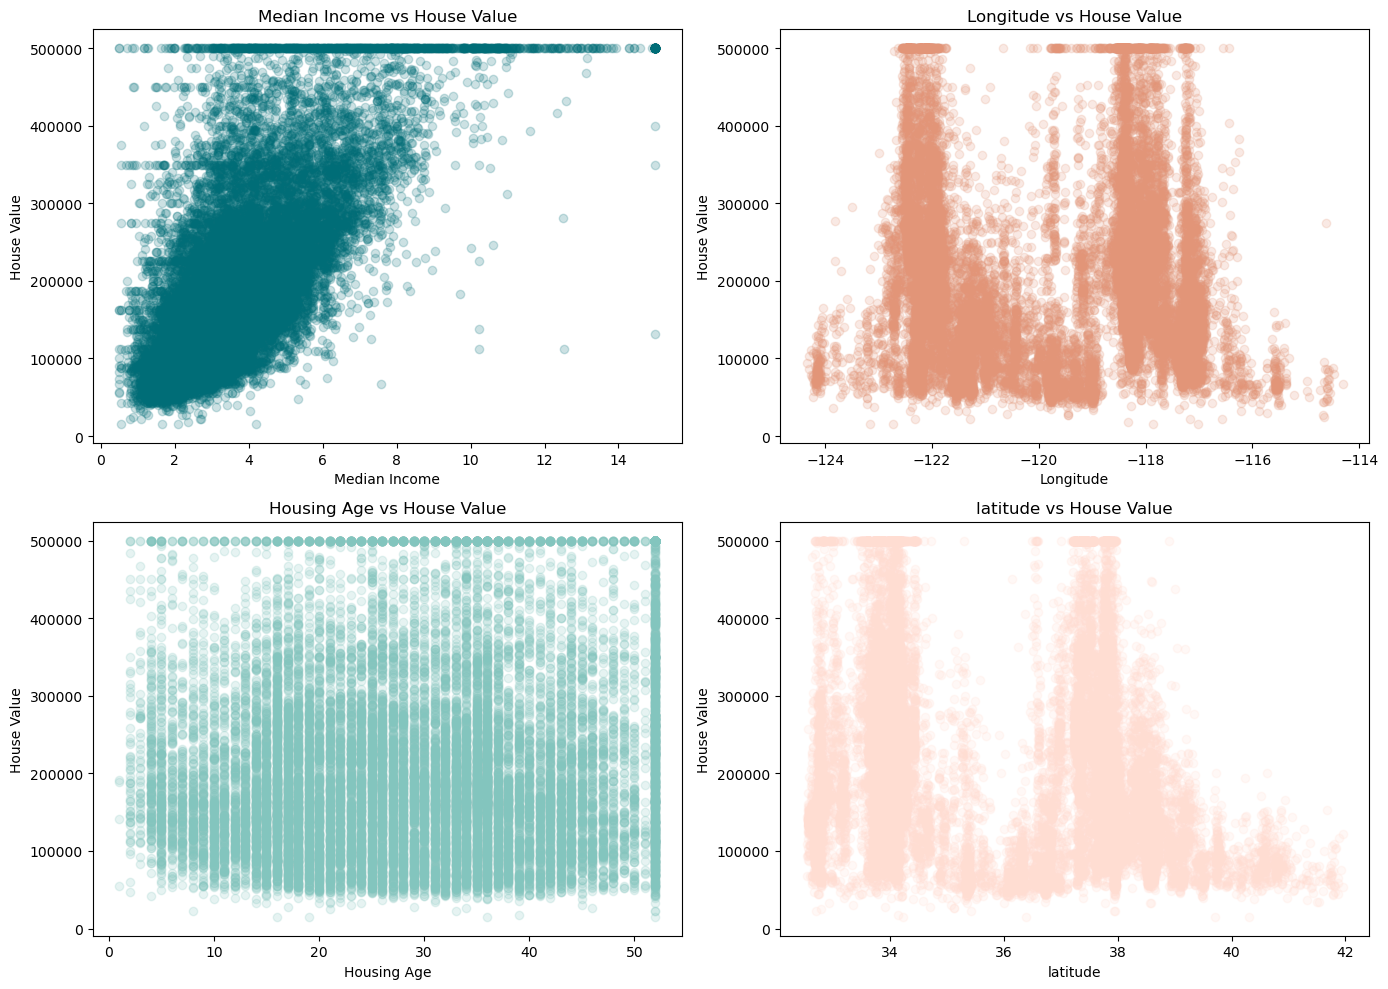

In [54]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs[0, 0].scatter(df_cleaned["median_income"],df_cleaned["median_house_value"], alpha=0.2, color="#006d77")
axs[0, 0].set_title("Median Income vs House Value")
axs[0, 0].set_xlabel("Median Income")
axs[0, 0].set_ylabel("House Value")

axs[1, 0].scatter(df_cleaned["housing_median_age"],df_cleaned["median_house_value"], alpha=0.2, color="#83c5be")
axs[1, 0].set_title("Housing Age vs House Value")
axs[1, 0].set_xlabel("Housing Age")
axs[1, 0].set_ylabel("House Value")


axs[0, 1].scatter(df_cleaned["longitude"],df_cleaned["median_house_value"], alpha=0.2, color="#e29578")
axs[0, 1].set_title("Longitude vs House Value")
axs[0, 1].set_xlabel("Longitude")
axs[0, 1].set_ylabel("House Value")


axs[1, 1].scatter(df_cleaned["latitude"],df_cleaned["median_house_value"], alpha=0.2, color="#ffddd2")
axs[1, 1].set_title("latitude vs House Value")
axs[1, 1].set_xlabel("latitude")
axs[1, 1].set_ylabel("House Value")


fig.tight_layout()

plt.show()

#### The scatter plot shows the positive relationship between median income and house value. Latitude and Longitude vary significantly depending on the city in California. Lastly, Housing age and house values show no clear relationship. 

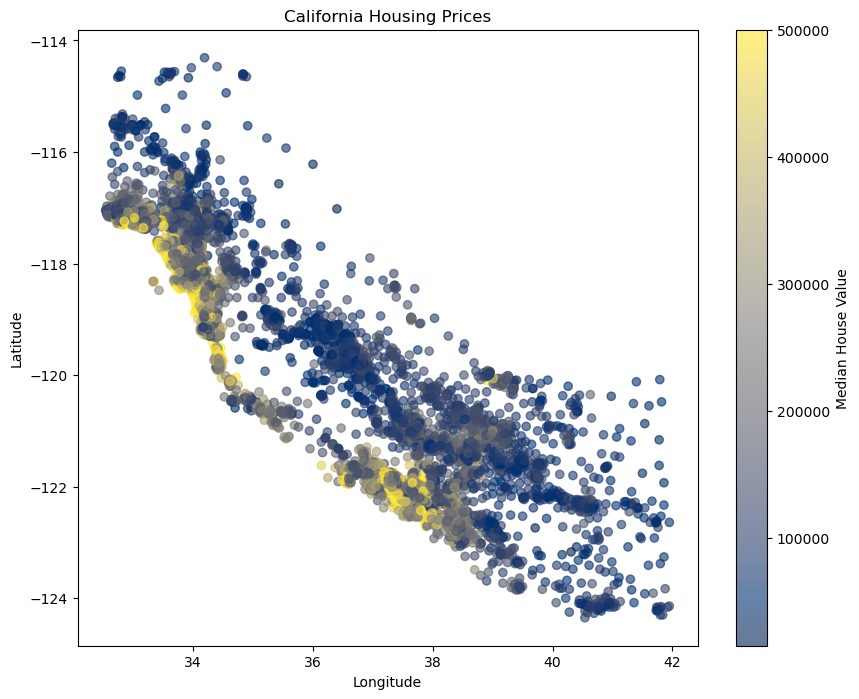

In [66]:
plt.figure(figsize=(10,8))

plt.scatter(df_cleaned["latitude"], df_cleaned["longitude"], c=df_cleaned["median_house_value"],cmap="cividis",alpha=0.6)

plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")

plt.ylabel("Latitude")
plt.title("California Housing Prices")

plt.show()

Since moving closer to the west gets the house closer to the coast, this scatter plot shows that houses near the sea are generally more expensive.